Epoch   0 | Train Loss: 0.7227 | Val Loss: 0.6956 | Train Acc: 43.61% | Val Acc: 47.50%
Epoch 100 | Train Loss: 0.2415 | Val Loss: 0.2880 | Train Acc: 92.22% | Val Acc: 90.00%
Epoch 200 | Train Loss: 0.2023 | Val Loss: 0.2760 | Train Acc: 94.17% | Val Acc: 90.83%
Epoch 300 | Train Loss: 0.1571 | Val Loss: 0.2888 | Train Acc: 95.28% | Val Acc: 90.83%
Epoch 400 | Train Loss: 0.1313 | Val Loss: 0.3002 | Train Acc: 95.83% | Val Acc: 91.67%

Final Test Accuracy with Dropout: 91.67%


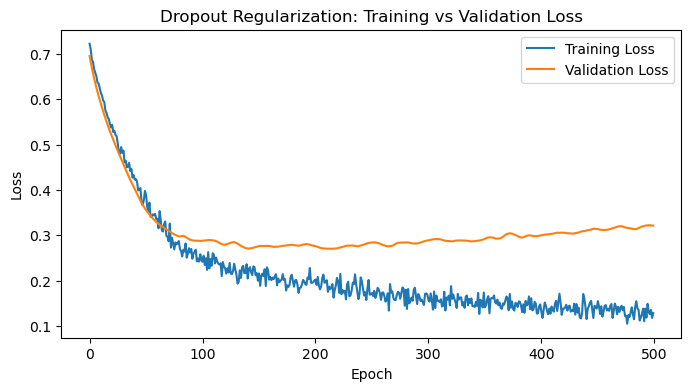

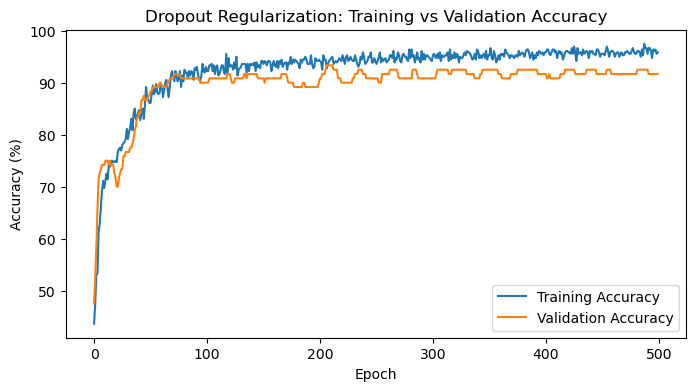

In [1]:
# Dropout Regularization Example
# Galaxy vs Star Classification

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(0)
torch.manual_seed(0)

X, y = make_classification(
    n_samples=600,
    n_features=6,
    n_informative=4,
    n_redundant=1,
    n_classes=2,
    class_sep=1.2,
    flip_y=0.08,
    random_state=0
)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

model = nn.Sequential(
    nn.Linear(6, 128),
    nn.ReLU(),
    nn.Dropout(p=0.4),

    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(p=0.3),

    nn.Linear(64, 2)
)

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 500

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    model.train()

    train_outputs = model(X_train)
    train_loss = loss_function(train_outputs, y_train)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    train_predictions = torch.argmax(train_outputs, dim=1)

    train_accuracy = (
        train_predictions == y_train
    ).float().mean() * 100

    model.eval()

    with torch.no_grad():

        val_outputs = model(X_val)
        val_loss = loss_function(val_outputs, y_val)

        val_predictions = torch.argmax(val_outputs, dim=1)

        val_accuracy = (
            val_predictions == y_val
        ).float().mean() * 100

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(train_accuracy.item())
    val_accuracies.append(val_accuracy.item())

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"Train Loss: {train_loss.item():.4f} | "
            f"Val Loss: {val_loss.item():.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Val Acc: {val_accuracy:.2f}%"
        )

model.eval()

with torch.no_grad():

    test_outputs = model(X_test)
    test_predictions = torch.argmax(test_outputs, dim=1)

    test_accuracy = (
        test_predictions == y_test
    ).float().mean() * 100

print(f"\nFinal Test Accuracy with Dropout: {test_accuracy:.2f}%")

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Dropout Regularization: Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Dropout Regularization: Training vs Validation Accuracy")
plt.legend()
plt.show()